# Glycol Line Blockage Diagnosis — Pressure Differential

Compares glycol supply pressure **at the pier** (MTMount) to the **chiller supply pressure** (MTCamera)
to detect abnormal pressure drops that would indicate a partial blockage in the glycol line.

| Source | Client | Topic | Field | Native units | Description |
|---|---|---|---|---|---|
| EFD (standard) | `EfdClient("usdf_efd")` | `lsst.sal.MTMount.cooling` | `glycolPressurePier0101` | **bar** | Pier glycol pressure (upstream of clog) |
| EFD (MTCamera Kafka db) | `EfdClient("usdf_efd", db_name="lsst.MTCamera")` | `chiller_Maq20` | `glycSupplyP` | **PSI** | Chiller glycol supply pressure |

> **Unit mismatch:** MTMount telemetry uses SI (bar); the MAQ20 DAQ reports in PSI.
> The chiller series is converted to bar (× 0.0689476) before computing ΔP.
>
> **MTCamera note:** `lsst.sal.MTCamera` in the standard EFD is unreliable; the dedicated
> `db_name="lsst.MTCamera"` Kafka database is used instead.

A growing **ΔP = P_pier − P_chiller** (both in bar) indicates increasing back-pressure
building up on the upstream side of the blockage.

**EFD alias:** `usdf_efd`

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from astropy.time import Time, TimeDelta
import astropy.units as u

from lsst_efd_client import EfdClient

%matplotlib inline

## Configuration

In [46]:
# ── EFD topics and fields ─────────────────────────────────────────────────────
TOPIC_PIER    = "lsst.sal.MTMount.cooling"
FIELD_PIER    = "glycolPressurePier0101"
LABEL_PIER    = "MTMount pier glycol pressure"
UNITS_PIER    = "bar"                  # MTMount uses SI

# MTCamera chiller is read from the separate lsst.MTCamera Kafka db;
# topic name there does NOT carry the lsst.sal.MTCamera prefix.
TOPIC_CHILLER = "lsst.MTCamera.chiller_maq20"
FIELD_CHILLER = "GlycSupplyP"
LABEL_CHILLER = "MTCamera chiller glycol supply pressure"
UNITS_CHILLER = "PSI"                  # MAQ20 DAQ uses PSI

# Unit conversion: bring both to bar
PSI_TO_BAR = 0.0689476                 # 1 PSI = 0.0689476 bar

# ── Known events ──────────────────────────────────────────────────────────────
# Glycol chiller was switched in early April.  The ΔP sign flip in the data
# (negative → ~+0.65 bar) pinpoints the transition to ~Apr 7; adjust if known.
CHILLER_SWITCH_DATE = "2026-04-07"     # approximate — update with exact date

# ── Time range ────────────────────────────────────────────────────────────────
LOOKBACK_DAYS = 90          # how many days back to query
t_end   = Time.now()
t_start = t_end - TimeDelta(LOOKBACK_DAYS * u.day)

print(f"Query window:")
print(f"  Start : {t_start.iso} UTC")
print(f"  End   : {t_end.iso}   UTC")
print(f"  Span  : {LOOKBACK_DAYS} days")
print(f"\nUnit conversion: {UNITS_CHILLER} → bar  (×{PSI_TO_BAR})")
print(f"Chiller switch date (approx.): {CHILLER_SWITCH_DATE}")

# ── Resampling ────────────────────────────────────────────────────────────────
RESAMPLE_FREQ = "5min"      # change to "1min" or "1h" as needed


Query window:
  Start : 2026-02-26 21:17:14.994 UTC
  End   : 2026-05-27 21:17:14.994   UTC
  Span  : 90 days

Unit conversion: PSI → bar  (×0.0689476)
Chiller switch date (approx.): 2026-04-07


## Connect to EFD

In [34]:
# Standard EFD client (MTMount and other lsst.sal topics)
client = EfdClient("usdf_efd")
print("Connected to EFD (standard)")

# Separate Kafka DB for MTCamera (more reliable than lsst.sal.MTCamera in usdf_efd)
client_mtcamera = EfdClient("usdf_efd", db_name="lsst.MTCamera")
print("Connected to EFD (lsst.MTCamera db)")


Connected to EFD (standard)
Connected to EFD (lsst.MTCamera db)


In [37]:
# Search available topics in the lsst.MTCamera Kafka db
all_topics_mtcamera = await client_mtcamera.get_topics()
print(f"Total topics in lsst.MTCamera db: {len(all_topics_mtcamera)}\n")

chiller_hits = [t for t in all_topics_mtcamera if "chiller" in t.lower()]
print(f"Chiller topics ({len(chiller_hits)}):")
for t in chiller_hits:
    print(f"  {t}")


Total topics in lsst.MTCamera db: 117

Chiller topics (3):
  lsst.MTCamera.chiller
  lsst.MTCamera.chiller_fpar
  lsst.MTCamera.chiller_maq20


In [38]:
# List fields in lsst.MTCamera.chiller_maq20
fields_maq20 = await client_mtcamera.get_fields("lsst.MTCamera.chiller_maq20")
print(f"lsst.MTCamera.chiller_maq20 fields ({len(fields_maq20)}):")
for f in sorted(fields_maq20):
    print(f"  {f}")


lsst.MTCamera.chiller_maq20 fields (43):
  AmbientTemp
  CabinetTemp
  ColdPlHeatXfer
  CoolantHXOut
  CoolantHeatXfer
  CoolantPumpIn
  CoolantPumpOut
  CoolantReturn
  CoolantSupply
  Fan1Speed
  Fan2Speed
  GlycChillerIn
  GlycChillerIn_state
  GlycChillerOut
  GlycChillerOut_state
  GlycCondensOut
  GlycDeSuHtrFlow
  GlycDeSuHtrFlow_state
  GlycDeSuHtrOut
  GlycFanIn
  GlycFanMinusAmb
  GlycFanMinusAmb_state
  GlycFanOut
  GlycHeatXfer
  GlycInputFlow
  GlycInputFlow_state
  GlycSupplyP
  PBurstReturn
  PBurstReturn_state
  PBurstSupply
  PBurstSupply_state
  Stg1CondensOut
  Stg1Discharge
  Stg1Return
  Stg1TXVBulb
  Stg1TXVBulb_state
  Stg2DeSuHtrOut
  Stg2Discharge
  Stg2DischargeP
  Stg2EvapIn
  Stg2EvapOut
  Stg2Return
  timestamp


In [14]:
# Show only the relevant field subsets (small output)
pier_glycol = [f for f in fields_pier if "glycol" in f.lower() or "pressure" in f.lower()]
print("MTMount.cooling — glycol/pressure fields:", pier_glycol)

chiller_glycol = [f for f in sorted(fields_chiller)
                  if "glyc" in f.lower() or "supply" in f.lower() or "pressure" in f.lower()]
print("chiller_Maq20  — glycol/supply/pressure fields:", chiller_glycol)


MTMount.cooling — glycol/pressure fields: ['glycolPressureAzimuth0001', 'glycolPressureAzimuth0001Timestamp', 'glycolPressureAzimuth0002', 'glycolPressureAzimuth0002Timestamp', 'glycolPressureAzimuth0003', 'glycolPressureAzimuth0003Timestamp', 'glycolPressureAzimuth0004', 'glycolPressureAzimuth0004Timestamp', 'glycolPressureAzimuth0005', 'glycolPressureAzimuth0005Timestamp', 'glycolPressureAzimuth0006', 'glycolPressureAzimuth0006Timestamp', 'glycolPressureAzimuth0007', 'glycolPressureAzimuth0007Timestamp', 'glycolPressureAzimuth0008', 'glycolPressureAzimuth0008Timestamp', 'glycolPressureAzimuth0009', 'glycolPressureAzimuth0009Timestamp', 'glycolPressureAzimuth0010', 'glycolPressureAzimuth0010Timestamp', 'glycolPressureAzimuth0011', 'glycolPressureAzimuth0011Timestamp', 'glycolPressureAzimuth0012', 'glycolPressureAzimuth0012Timestamp', 'glycolPressureAzimuth0013', 'glycolPressureAzimuth0013Timestamp', 'glycolPressureAzimuth0014', 'glycolPressureAzimuth0014Timestamp', 'glycolPressureAzim

In [15]:
import pathlib
out_pier = [f for f in fields_pier if "glycol" in f.lower() or "pressure" in f.lower()]
out_chiller = [f for f in sorted(fields_chiller) if "glyc" in f.lower() or "supply" in f.lower() or "pressure" in f.lower()]
pathlib.Path("/tmp/efd_fields_check.txt").write_text(
    f"MTMount.cooling glycol/pressure:\n" + "\n".join(f"  {f}" for f in out_pier) +
    f"\n\nchiller_Maq20 glycol/supply/pressure:\n" + "\n".join(f"  {f}" for f in out_chiller)
)
print("Written to /tmp/efd_fields_check.txt")
print("pier count:", len(out_pier), "  chiller count:", len(out_chiller))


Written to /tmp/efd_fields_check.txt
pier count: 66   chiller count: 13


In [ ]:
# Inspect individual series statistics to identify unit mismatch
print(f"=== Pier pressure ({FIELD_PIER}) ===")
print(pier_rs.describe())
print()
print("=== Chiller supply pressure (glycSupplyP) ===")
print(chiller_rs.describe())
print()
# 1 bar = 14.5038 PSI  |  1 PSI = 0.0689476 bar
BAR_TO_PSI = 14.5038
PSI_TO_BAR = 1 / BAR_TO_PSI
print(f"If pier is bar and chiller is PSI → chiller in bar: {chiller_rs.median() * PSI_TO_BAR:.2f}")
print(f"If pier is PSI and chiller is bar → pier in bar:    {pier_rs.median()    * PSI_TO_BAR:.2f}")


=== Pier pressure (glycolPressurePier0102) ===
count    15931.000000
mean         1.043139
std          0.544588
min          0.472463
25%          0.738759
50%          0.811032
75%          0.888065
max          2.373934
Name: MTMount pier glycol pressure, dtype: float64

=== Chiller supply pressure (glycSupplyP) ===
count    17048.000000
mean        23.959514
std          8.645929
min          6.714801
25%         15.593833
50%         26.192432
75%         32.144662
max         38.874637
Name: MTCamera chiller glycol supply pressure, dtype: float64

If pier is bar and chiller is PSI → chiller in bar: 1.81
If pier is PSI and chiller is bar → pier in bar:    0.06


## Fetch Pressure Data

> **Note:** A 60-day query on a high-rate topic can be slow and return millions of rows.
> The resampled series is what is used for plotting.

In [47]:
print(f"Fetching {LABEL_PIER} from {TOPIC_PIER} …")
df_pier = await client.select_time_series(
    TOPIC_PIER,
    fields=[FIELD_PIER],
    start=t_start,
    end=t_end,
)
print(f"  → {len(df_pier):,} rows")

print(f"\nFetching {LABEL_CHILLER} from {TOPIC_CHILLER} (lsst.MTCamera db) …")
df_chiller = await client_mtcamera.select_time_series(
    TOPIC_CHILLER,
    fields=[FIELD_CHILLER],
    start=t_start,
    end=t_end,
)
print(f"  → {len(df_chiller):,} rows")

print("\nDone.")


Fetching MTMount pier glycol pressure from lsst.sal.MTMount.cooling …
  → 25,602,298 rows

Fetching MTCamera chiller glycol supply pressure from lsst.MTCamera.chiller_maq20 (lsst.MTCamera db) …
  → 1,059,579 rows

Done.


## Resample and Align

In [48]:
pier_rs    = df_pier[FIELD_PIER].resample(RESAMPLE_FREQ).mean().rename(LABEL_PIER)
chiller_rs = (df_chiller[FIELD_CHILLER].resample(RESAMPLE_FREQ).mean() * PSI_TO_BAR
              ).rename(LABEL_CHILLER)

# Align on common timestamps
common_idx = pier_rs.index.intersection(chiller_rs.index)
pier_al    = pier_rs.reindex(common_idx)
chiller_al = chiller_rs.reindex(common_idx)

# Pressure differential: pier (upstream) − chiller supply  (both now in bar)
delta_p = (pier_al - chiller_al).rename("ΔP  (pier − chiller)  [bar]")

print(f"Resampled rows (each series): {len(pier_rs):,}  /  {len(chiller_rs):,}")
print(f"Common aligned rows         : {len(common_idx):,}")
print(f"\nPier pressure  [{UNITS_PIER}]:")
print(pier_rs.describe().to_string())
print(f"\nChiller pressure (converted to bar from {UNITS_CHILLER}):")
print(chiller_rs.describe().to_string())
print(f"\nΔP statistics [bar]:")
print(delta_p.describe().to_string())


Resampled rows (each series): 25,921  /  25,921
Common aligned rows         : 25,921

Pier pressure  [bar]:
count    24396.000000
mean         2.631872
std          0.548085
min          1.077900
25%          2.464220
50%          2.704908
75%          3.003807
max          3.993890

Chiller pressure (converted to bar from PSI):
count    24909.000000
mean         2.596156
std          1.301953
min          0.471116
25%          1.332791
50%          2.336570
75%          3.909218
max          5.487749

ΔP statistics [bar]:
count    23778.000000
mean        -0.008703
std          1.169082
min         -2.984794
25%         -1.162573
50%          0.644293
75%          0.843394
max          3.161179


## Plot — Individual Pressures and Differential

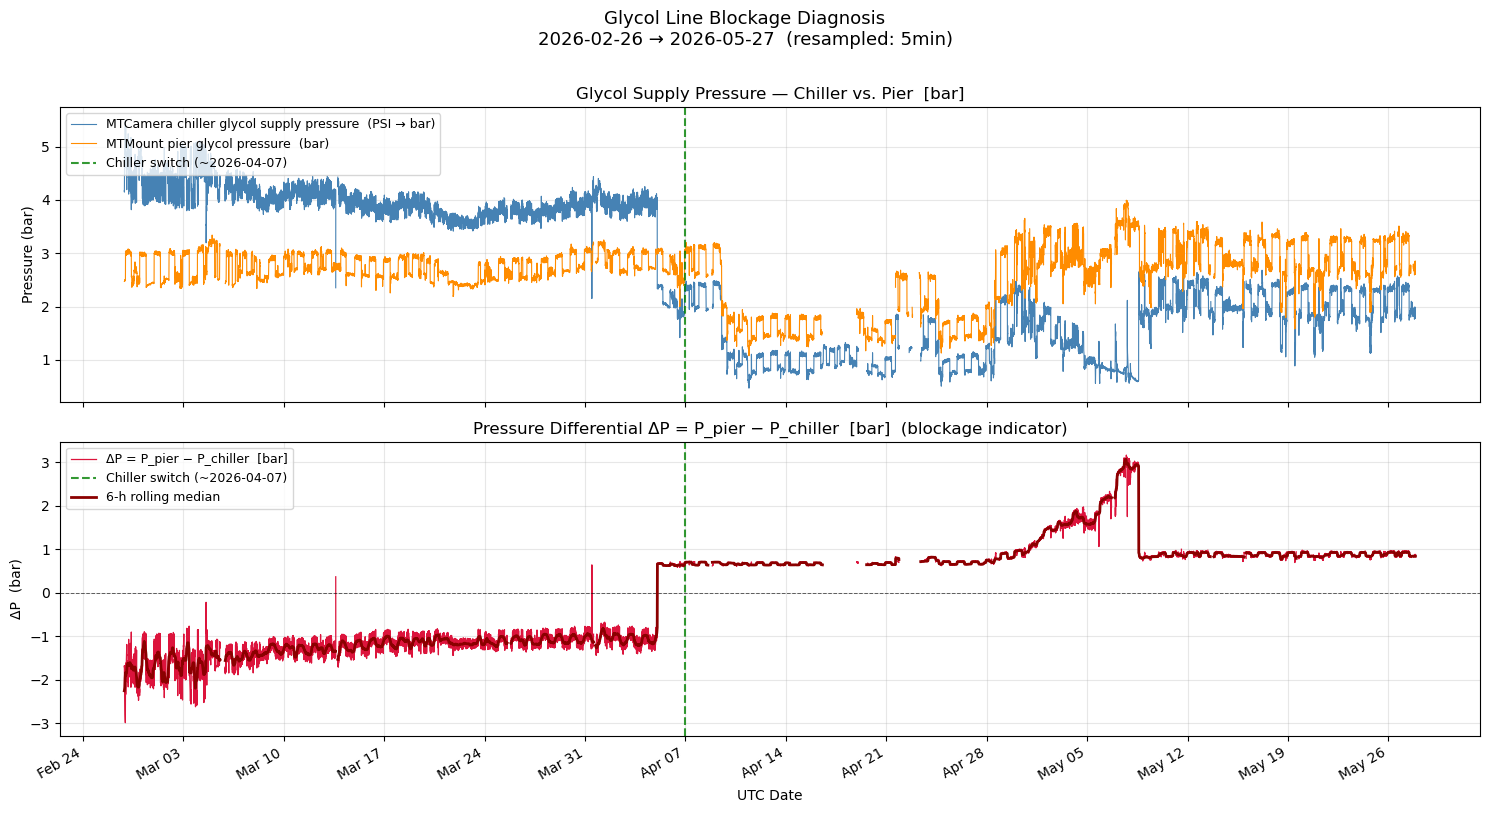

In [49]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

switch_dt = pd.Timestamp(CHILLER_SWITCH_DATE, tz="UTC")

# ── Top panel: raw pressures (both in bar) ────────────────────────────────────
ax0 = axes[0]
ax0.plot(chiller_rs.index, chiller_rs.values, lw=0.8, color="steelblue",
         label=f"{LABEL_CHILLER}  ({UNITS_CHILLER} → bar)")
ax0.plot(pier_rs.index, pier_rs.values, lw=0.8, color="darkorange",
         label=f"{LABEL_PIER}  ({UNITS_PIER})")
ax0.axvline(switch_dt, color="green", lw=1.5, ls="--", alpha=0.8,
            label=f"Chiller switch (~{CHILLER_SWITCH_DATE})")
ax0.set_ylabel("Pressure (bar)", fontsize=10)
ax0.set_title("Glycol Supply Pressure — Chiller vs. Pier  [bar]", fontsize=12)
ax0.legend(fontsize=9, loc="upper left")
ax0.grid(True, alpha=0.3)

# ── Bottom panel: pressure differential ──────────────────────────────────────
ax1 = axes[1]
ax1.plot(delta_p.index, delta_p.values, lw=0.9, color="crimson",
         label="ΔP = P_pier − P_chiller  [bar]")
ax1.axhline(0, color="black", lw=0.7, ls="--", alpha=0.6)
ax1.axvline(switch_dt, color="green", lw=1.5, ls="--", alpha=0.8,
            label=f"Chiller switch (~{CHILLER_SWITCH_DATE})")

# Rolling median trend overlay (6-hour window)
window_pts = max(1, int(pd.Timedelta("6h") / pd.Timedelta(RESAMPLE_FREQ)))
trend = delta_p.rolling(window=window_pts, center=True, min_periods=window_pts // 2).median()
ax1.plot(trend.index, trend.values, lw=2.0, color="darkred", ls="-",
         label="6-h rolling median")

ax1.set_ylabel("ΔP  (bar)", fontsize=10)
ax1.set_xlabel("UTC Date", fontsize=10)
ax1.set_title("Pressure Differential ΔP = P_pier − P_chiller  [bar]  (blockage indicator)",
              fontsize=12)
ax1.legend(fontsize=9, loc="upper left")
ax1.grid(True, alpha=0.3)

# ── Formatting ────────────────────────────────────────────────────────────────
date_fmt = mdates.DateFormatter("%b %d")
axes[-1].xaxis.set_major_formatter(date_fmt)
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
fig.autofmt_xdate(rotation=30, ha="right")

fig.suptitle(
    f"Glycol Line Blockage Diagnosis\n"
    f"{t_start.datetime.strftime('%Y-%m-%d')} → {t_end.datetime.strftime('%Y-%m-%d')}  "
    f"(resampled: {RESAMPLE_FREQ})",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()


## Rolling Statistics — Trend Analysis

A monotonically increasing rolling-median ΔP over time is a strong indicator
of a growing restriction.  The table below shows weekly-median ΔP for quick scanning.

In [50]:
weekly = delta_p.resample("1W").agg(["median", "mean", "std", "min", "max"])
weekly.columns = ["median_dP", "mean_dP", "std_dP", "min_dP", "max_dP"]
weekly.index = weekly.index.strftime("%Y-%m-%d")
weekly.index.name = "week_end"

print("Weekly ΔP summary (bar):")
display(weekly.round(4))

Weekly ΔP summary (bar):


,median_dP,mean_dP,std_dP,min_dP,max_dP
week_end,,,,,
2026-03-01,-1.7458,-1.7322,0.3553,-2.9848,-0.8962
2026-03-08,-1.4599,-1.5073,0.3000,-2.6187,-0.2192
2026-03-15,-1.2611,-1.2681,0.1467,-1.7079,0.3672
2026-03-22,-1.1286,-1.1297,0.1202,-1.5019,-0.8262
2026-03-29,-1.1042,-1.0985,0.1164,-1.3630,-0.8093
2026-04-05,-1.0162,-0.8145,0.6029,-1.4380,0.7030
2026-04-12,0.6578,0.6642,0.0308,0.5822,0.7236
2026-04-19,0.6473,0.6622,0.0257,0.6144,0.7086
2026-04-26,0.6964,0.6998,0.0534,0.6207,0.8348


## Optional — Verify Field Names

Run these cells once to confirm that the expected fields exist in each topic
before running a long multi-day query.

In [ ]:
# Quick spot-check: last 10 samples from each topic
df_pier_check = await client.select_top_n(
    TOPIC_PIER, fields=[FIELD_PIER], num=10
)
print(f"{TOPIC_PIER}  /  {FIELD_PIER}")
display(df_pier_check.sort_index())

In [ ]:
df_chiller_check = await client_mtcamera.select_top_n(
    TOPIC_CHILLER, fields=[FIELD_CHILLER], num=10
)
print(f"{TOPIC_CHILLER}  /  {FIELD_CHILLER}  (lsst.MTCamera db)")
display(df_chiller_check.sort_index())
